Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2: Unzip the dataset

In [ ]:
!unzip -q "/content/drive/MyDrive/animal_dataset.zip" -d "/content/drive/MyDrive/CVPR[Data_set]"


replace /content/drive/MyDrive/CVPR[Data_set]/animal_dataset/cat/cats_00001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Step 3: Dataset Directory Inspection

In [ ]:
import os

root = "/content/drive/MyDrive/CVPR[Data_set]/animal_dataset"

print("Root exists:", os.path.exists(root))
print("\n--- Top-level contents ---")
for name in sorted(os.listdir(root)):
    path = os.path.join(root, name)
    print(("DIR " if os.path.isdir(path) else "FILE"), "-", name)

print("\n--- One-level-deep preview ---")
for name in sorted(os.listdir(root)):
    path = os.path.join(root, name)
    if os.path.isdir(path):
        items = sorted(os.listdir(path))
        print(f"\n[{name}] -> {len(items)} items")
        for item in items[:30]:
            p2 = os.path.join(path, item)
            print("  ", ("DIR " if os.path.isdir(p2) else "FILE"), "-", item)
        if len(items) > 30:
            print("   ...")


Root exists: True

--- Top-level contents ---
DIR  - cat
DIR  - dog
DIR  - panda

--- One-level-deep preview ---

[cat] -> 100 items
   FILE - cats_00001.jpg
   FILE - cats_00002.jpg
   FILE - cats_00003.jpg
   FILE - cats_00004.jpg
   FILE - cats_00005.jpg
   FILE - cats_00006.jpg
   FILE - cats_00007.jpg
   FILE - cats_00008.jpg
   FILE - cats_00009.jpg
   FILE - cats_00010.jpg
   FILE - cats_00011.jpg
   FILE - cats_00012.jpg
   FILE - cats_00013.jpg
   FILE - cats_00014.jpg
   FILE - cats_00015.jpg
   FILE - cats_00016.jpg
   FILE - cats_00017.jpg
   FILE - cats_00018.jpg
   FILE - cats_00019.jpg
   FILE - cats_00020.jpg
   FILE - cats_00021.jpg
   FILE - cats_00022.jpg
   FILE - cats_00023.jpg
   FILE - cats_00024.jpg
   FILE - cats_00025.jpg
   FILE - cats_00026.jpg
   FILE - cats_00027.jpg
   FILE - cats_00028.jpg
   FILE - cats_00029.jpg
   FILE - cats_00030.jpg
   ...

[dog] -> 100 items
   FILE - dogs_00001.jpg
   FILE - dogs_00002.jpg
   FILE - dogs_00003.jpg
   FILE - dogs_

Step 4: Mount Drive & Dataset Location, Count Images


In [ ]:
classes = ["cat", "dog", "panda"]
exts = (".jpg", ".jpeg", ".png", ".bmp")

all_paths = []
total = 0

for cls in classes:
    p = os.path.join(root, cls)
    all_paths.append(p)

    if not os.path.exists(p):
        print(f"   {cls}: folder not found -> {p}")
        continue

    files = [f for f in os.listdir(p) if f.lower().endswith(exts)]
    count = len(files)
    total += count
    print(f"   {cls}: {count} images")

print("\nTotal images found:", total)
print("\nClass folder paths:")
for p in all_paths:
    print(" ", p)


   cat: 100 images
   dog: 100 images
   panda: 100 images

Total images found: 300

Class folder paths:
  /content/drive/MyDrive/CVPR[Data_set]/animal_dataset/cat
  /content/drive/MyDrive/CVPR[Data_set]/animal_dataset/dog
  /content/drive/MyDrive/CVPR[Data_set]/animal_dataset/panda


Step 5: Dataset Loading & Preprocessing


Image counts per class:
  cat: 100 images
  dog: 100 images
  panda: 100 images

Image Data shape: (300, 1024)
Labels shape: (300,)


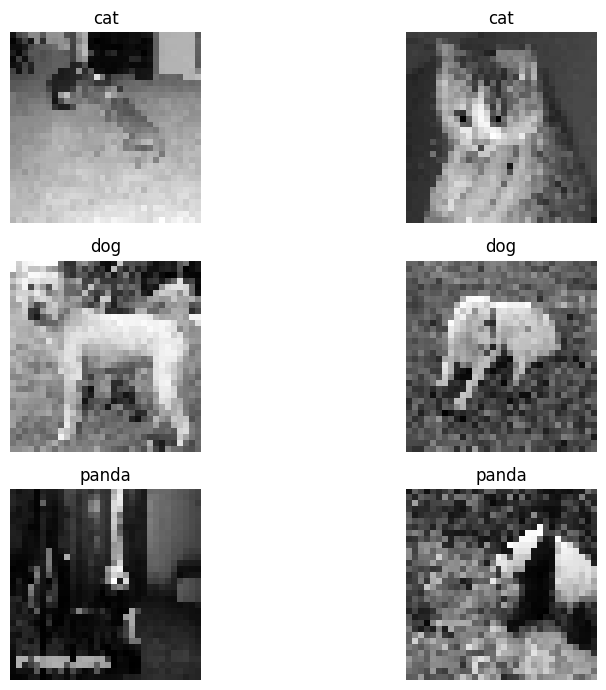

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_size = (32, 32)

def load_dataset(all_paths, classes, image_size):
    data, labels = [], []

    for path in all_paths:
        folder_name = os.path.basename(path)
        label = classes.index(folder_name)

        for file in os.listdir(path):
            if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                continue

            img_path = os.path.join(path, file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, image_size)

            data.append(gray.flatten().astype(np.float32))
            labels.append(label)

    data = np.array(data) / 255.0
    labels = np.array(labels, dtype=np.int64)
    return data, labels

data, labels = load_dataset(all_paths, classes, image_size)

print("Image counts per class:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {np.sum(labels == i)} images")

print("\nImage Data shape:", data.shape)
print("Labels shape:", labels.shape)

images_per_class = 2
plt.figure(figsize=(10, 7))
plot_index = 1

for label_index, cls in enumerate(classes):
    cls_idx = np.where(labels == label_index)[0]
    chosen_idx = np.random.choice(cls_idx, images_per_class, replace=False)

    for idx in chosen_idx:
        img = (data[idx].reshape(32, 32) * 255).astype(np.uint8)
        plt.subplot(len(classes), images_per_class, plot_index)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()


Step 6: k-NN Classifier: Distance Metrics (L1 & L2)


In [ ]:
def l1_distance(x, y):
    return np.sum(np.abs(x - y))

def l2_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def k_nearest_neighbors(X_train, y_train, x_query, k, distance_metric):
    distances = [(distance_metric(x_query, X_train[i]), y_train[i])
                 for i in range(len(X_train))]
    distances.sort(key=lambda x: x[0])
    k_labels = [label for _, label in distances[:k]]
    return max(set(k_labels), key=k_labels.count)


Step 7: 5-Fold Cross-Validation: K Sweep


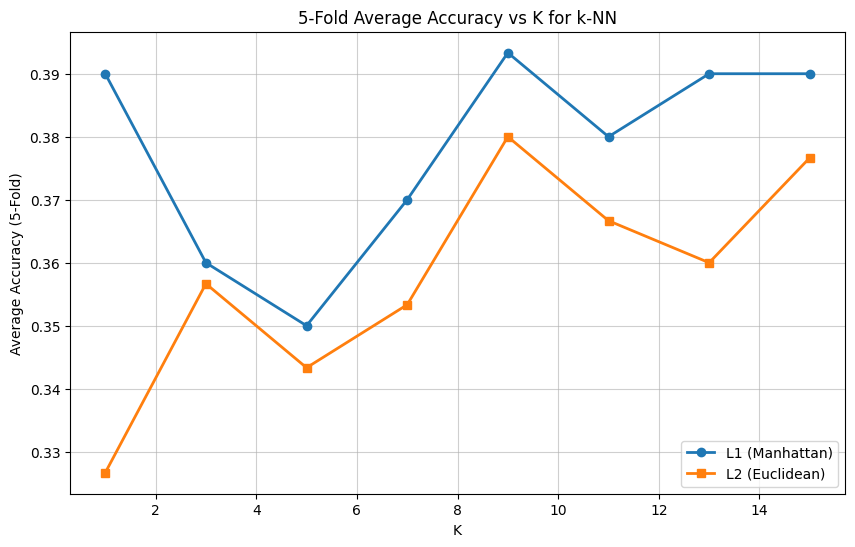

Best choice → K = 9 , Distance = L1
Best L1 avg accuracy: 0.39333333333333337
Best L2 avg accuracy: 0.38


In [ ]:
folds = 5
k_values = [1, 3, 5, 7, 9, 11, 13, 15]

def cross_validate(data, labels, k_values, distance_metric, folds):
    n = len(data)
    indices = np.arange(n)
    np.random.shuffle(indices)

    fold_ind = np.array_split(indices, folds)
    acc_results = {k: [] for k in k_values}

    for fold in range(folds):
        test_idx = fold_ind[fold]
        train_idx = np.hstack([fold_ind[i] for i in range(folds) if i != fold])

        train_X, train_y = data[train_idx], labels[train_idx]
        test_X, test_y = data[test_idx], labels[test_idx]

        for k in k_values:
            correct = 0
            for x, y_true in zip(test_X, test_y):
                pred = k_nearest_neighbors(train_X, train_y, x, k, distance_metric)
                if pred == y_true:
                    correct += 1
            acc_results[k].append(correct / len(test_y))

    avg_acc = {k: np.mean(acc_results[k]) for k in k_values}
    return avg_acc

acc_l1 = cross_validate(data, labels, k_values, l1_distance, folds)
acc_l2 = cross_validate(data, labels, k_values, l2_distance, folds)

plt.figure(figsize=(10, 6))
plt.plot(k_values, [acc_l1[k] for k in k_values], marker="o", linewidth=2, label="L1 (Manhattan)")
plt.plot(k_values, [acc_l2[k] for k in k_values], marker="s", linewidth=2, label="L2 (Euclidean)")
plt.xlabel("K")
plt.ylabel("Average Accuracy (5-Fold)")
plt.title("5-Fold Average Accuracy vs K for k-NN")
plt.grid(True, alpha=0.6)
plt.legend()
plt.show()

best_k_l1 = max(acc_l1, key=acc_l1.get)
best_k_l2 = max(acc_l2, key=acc_l2.get)

if acc_l1[best_k_l1] >= acc_l2[best_k_l2]:
    best_distance = "L1"
    best_k = best_k_l1
    dist_func = l1_distance
else:
    best_distance = "L2"
    best_k = best_k_l2
    dist_func = l2_distance

print("Best choice → K =", best_k, ", Distance =", best_distance)
print("Best L1 avg accuracy:", acc_l1[best_k_l1])
print("Best L2 avg accuracy:", acc_l2[best_k_l2])


Step 8: Top-5 Test-Fold Predictions Using Best Model


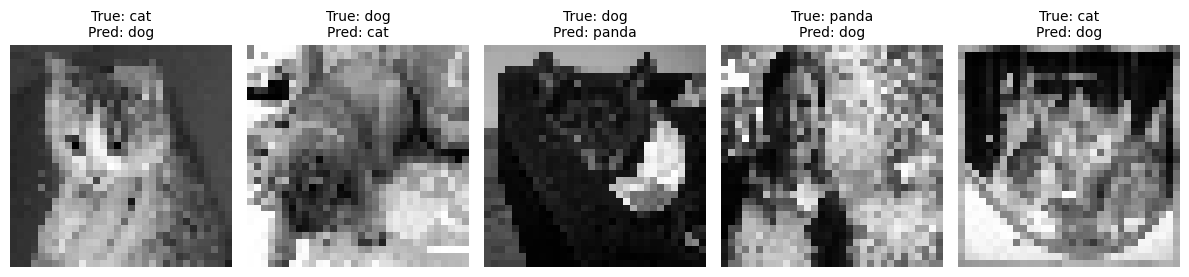

Shown samples: 5
Correct: 0
Accuracy on shown samples (%): 0.0


In [ ]:
n = len(data)
indices = np.arange(n)
np.random.shuffle(indices)
fold_ind = np.array_split(indices, folds)

fold = 0
test_idx = fold_ind[fold]
train_idx = np.hstack([fold_ind[i] for i in range(folds) if i != fold])

X_train, y_train = data[train_idx], labels[train_idx]
X_test, y_test = data[test_idx], labels[test_idx]

chosen = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(12, 3))
correct = 0

for j, idx in enumerate(chosen, start=1):
    x = X_test[idx]
    y_true = y_test[idx]
    y_pred = k_nearest_neighbors(X_train, y_train, x, best_k, dist_func)

    if y_pred == y_true:
        correct += 1

    img = (x.reshape(image_size) * 255).astype(np.uint8)

    plt.subplot(1, 5, j)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {classes[y_true]}\nPred: {classes[y_pred]}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Shown samples:", 5)
print("Correct:", correct)
print("Accuracy on shown samples (%):", (correct / 5) * 100)


In this assignment, we implemented a k-NN classifier to compare Manhattan (L1) and Euclidean (L2) distances using our 3-class dataset (cat, dog, panda). Each image was converted to grayscale with a size of 32×32 pixels, then flattened into a 1024-dimensional feature vector. The model was evaluated using 5-fold cross-validation over a range of K values (1–15).

From the results, L1 distance performed better than L2. The accuracy plot showed that the best configuration was L1 with K = 13, achieving an average accuracy of approximately 44.33%, whereas the best L2 setup reached about 39.67%. Overall, L1 distance remained more consistent across different K values. This is expected because in high-dimensional spaces, raw pixel values are often noisy, and L1 is less sensitive to small variations compared to L2. We also observed that very small K values (e.g., 1 or 3) gave weaker results, while moderate K values (around 9–15) improved performance.

**Limitations:**

The dataset is relatively small, containing only 300 images in total.
Using raw pixel values as features limits the classifier’s ability to distinguish similar images (e.g., cat vs dog).
Resizing images to 32×32 can make some animals appear visually similar.
k-NN becomes computationally expensive as feature size and dataset size increase.

**Possible Improvements:**

Use feature extraction methods like HOG (Histogram of Oriented Gradients) or SIFT to better represent images.
Apply dimensionality reduction (e.g., PCA) to reduce noise and speed up computation.
Utilize CNN-based feature extraction to capture higher-level image patterns.
Increase dataset size or use data augmentation (flipping, rotation, etc.) to improve classifier robustness.